```
U-Net (Semantic Segmentation)
   Every pixel → class label
   Output: one mask for whole image
   Use case: medical imaging, roads, sky

   Input: chest X-ray
   Output: lung region mask (all pixels)

Mask R-CNN (Instance Segmentation)
   Detect objects first → then mask each one
   Output: one mask per detected object
   Use case: counting objects, robotics

   Input: street photo
   Output: separate mask for car#1, car#2, person#1...
```

In [ ]:
!pip install roboflow albumentations segmentation_models_pytorch --quiet

In [ ]:
import os
import cv2
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
  print(f"   GPU  : {torch.cuda.get_device_name(0)}")
  print(f"   VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

```
COCO format (for Mask R-CNN / Detectron2):
   images/ + _annotations.coco.json
   → stores polygons, one JSON for all annotations

PNG Mask format (for U-Net):
   images/  ← RGB images
   masks/   ← grayscale PNG where pixel value = class id
   → one mask file per image, same filename

Example:
   images/dog_001.jpg  →  masks/dog_001.png
                           pixel=0 → background
                           pixel=255 → object (binary)
                           pixel=1,2,3... → classes (multi-class)
```

In [ ]:
from roboflow import Roboflow

API_KEY = 'YOUR_API_KEY_HERE'
WORKSPACE = 'YOUR_WORKSPACE_HERE'
PROJECT_NAME = 'YOUR_PROJECT_NAME_HERE'
VERSION = 1

rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
dataset = project.version(VERSION).download('png-mask-semantic')

DATASET_DIR = dataset.location
print(f"Dataset at: {DATASET_DIR}")

In [ ]:
for split in ['train', 'valid', 'test']:
  img_dir = os.path.join(DATASET_DIR, split, 'images')
  mask_dir = os.path.join(DATASET_DIR, split, 'masks')
  if os.path.exists(img_dir):
    n_imgs = len([f for f in os.listdir(img_dir) if not f.startwith('.')])
    n_masks = len([f for f in os.listdir(mask_dir) if not f.startwith('.')]) if os.path.exists(mask_dir) else 0
    print(f"   {split}/images  → {n_imgs} images")
    print(f"   {split}/masks   → {n_masks} masks")

In [ ]:
train_img_dir = os.path.join(DATASET_DIR, 'train', 'images')
train_mask_dir = os.path.join(DATASET_DIR, 'train', 'masks')
val_img_dir = os.path.join(DATASET_DIR, 'valid', 'images')
val_mask_dir = os.path.join(DATASET_DIR, 'valid', 'masks')

In [ ]:
train_img_dir = os.path.join(DATASET_DIR, 'train')
sample_img_name = sorted(os.listdir(train_img_dir))[0]
sample_img_path = os.path.join(train_img_dir, sample_img_name)

In [ ]:
base_name = os.path.splitext(sample_img_name)[0]
mask_name = base_name + '.png'
mask_path = os.path.join(train_mask_dir, mask_name)

In [ ]:
base_name = os.path.splitext(sample_img_name)[0]
mask_path = os.path.join(train_mask_dir, f"{base_name}_mask.png")

if not os.path.exists(sample_img_path):
    print(f"Image not found: {sample_img_path}")
elif not os.path.exists(mask_path):
    print(f"Mask not found: {mask_path}")
else:
    img = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(img)
    axes[0].set_title(f'Image\n{img.shape}', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f'Mask (raw)\n{mask.shape}', fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(mask > 127, cmap='hot')
    axes[2].set_title('Mask (thresholded > 127)', fontsize=11)
    axes[2].axis('off')

    plt.suptitle('Sample Image-Mask Pair', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"Image shape  : {img.shape}   (H, W, C)")
    print(f"Mask shape   : {mask.shape}   (H, W)")
    print(f"Mask dtype   : {mask.dtype}")
    print(f"Unique mask values: {np.unique(mask)}")

`albumentations` to resize + augment in one clean pipeline.

In [ ]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=15, p=0.3),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

```
Dataset for binary semantic segmentation.
    Reads image + corresponding PNG mask from disk.

    Expected folder structure:
        image_dir/  dog.jpg, cat.jpg ...
        mask_dir/   dog.png, cat.png ...  (same base name, .png extension)

    Returns:
        image : FloatTensor (3, H, W) — normalized
        mask  : FloatTensor (1, H, W) — binary 0.0 or 1.0
        
    BCEWithLogitsLoss expects (B, 1, H, W) predictions and (B, 1, H, W) targets
```

In [ ]:
class SegmentationDataset(Dataset):
  def __init__(self, image_dir, mask_dir, transforms=None):
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.transforms = transforms

    IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    self.images = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith(IMAGE_EXTS)
    ])

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    img_name = self.images[idx]
    image = cv2.imread(os.path.join(self.image_dir, img_name))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    base = os.path.splitext(img_name)[0]
    mask_path = os.path.join(self.mask_dir, f"{base}_mask.png")

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

    # Convert all non-zero labels to 1 (Foreground)
    mask = (mask > 0).astype(np.float32)

    if self.transforms:
      augmented = self.transforms(image=image, mask=mask)
      image = augmented['image']
      mask = augmented['mask']

    # Ensure mask has channel dim (1, H, W)
    if len(mask.shape) == 2:
        mask = mask.unsqueeze(0)

    return image, mask

In [ ]:
# Fix: The directories don't have nested 'images' and 'masks' subfolders in this project version
train_img_dir = os.path.join(DATASET_DIR, 'train')
train_mask_dir = os.path.join(DATASET_DIR, 'train')
val_img_dir = os.path.join(DATASET_DIR, 'valid')
val_mask_dir = os.path.join(DATASET_DIR, 'valid')

train_dataset = SegmentationDataset(train_img_dir, train_mask_dir, transforms=train_transform)
val_dataset = SegmentationDataset(val_img_dir, val_mask_dir, transforms=val_transform)

In [ ]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\n Train batches : {len(train_loader)}")
print(f" Val batches   : {len(val_loader)}")

In [ ]:
images, masks = next(iter(train_loader))
print(f"\n Batch shapes:")
print(f"   images: {images.shape}   (B, C, H, W)")
print(f"   masks : {masks.shape}   (B, 1, H, W)")
print(f"   mask value range: {masks.min():.0f} to {masks.max():.0f}  (should be 0 to 1)")

```
Both guides:   Conv → ReLU → Conv → ReLU
This notebook: Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU

BatchNorm normalizes the output of each layer during training.
Benefits:
  - Trains faster and more stably
  - Less sensitive to learning rate
  - Acts as mild regularization
The original U-Net paper didn't use BN (2015), but every modern implementation does.
```

```
INPUT IMAGE  (3 × H × W)
      │
      ▼
┌─────────────────────────────────────────────────────────┐
│  ENCODER (Contracting Path)                             │
│                                                         │
│  DoubleConv → [d1: 64 ch]  ──────────────────────────┐ │
│       ↓ MaxPool                                       │ │  ← skip connection 1
│  DoubleConv → [d2: 128 ch] ───────────────────────┐  │ │
│       ↓ MaxPool                                    │  │ │  ← skip connection 2
│  DoubleConv → [d3: 256 ch] ────────────────────┐  │  │ │
│       ↓ MaxPool                                │  │  │ │  ← skip connection 3
│  DoubleConv → [d4: 512 ch] ─────────────────┐  │  │  │ │
│       ↓ MaxPool                              │  │  │  │ │  ← skip connection 4
└──────────────────────────────────────────────┼──┼──┼──┘ │
                                               │  │  │    │
┌──────────────────────────────────────────────┼──┼──┼────┤
│  BOTTLENECK                                  │  │  │    │
│  DoubleConv → [1024 ch]                      │  │  │    │
└──────────────────────────────────────────────┼──┼──┼────┘
                                               │  │  │
┌──────────────────────────────────────────────┼──┼──┼──────┐
│  DECODER (Expanding Path)                    │  │  │      │
│                                              │  │  │      │
│  ConvTranspose2d (upsample) ← cat[d4] ───────┘  │  │      │
│  DoubleConv → [512 ch]                          │  │      │
│       ↑ ConvTranspose2d     ← cat[d3] ──────────┘  │      │
│  DoubleConv → [256 ch]                              │      │
│       ↑ ConvTranspose2d     ← cat[d2] ──────────────┘      │
│  DoubleConv → [128 ch]                                      │
│       ↑ ConvTranspose2d     ← cat[d1] ─────────────────────┘
│  DoubleConv → [64 ch]                                        │
│       ↓ Conv1×1
└────────────────────────────────────────────────────────────

OUTPUT MASK  (1 × H × W)  — one value per pixel
```

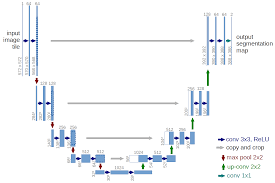

In [ ]:
class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.block = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.block(x)

test_block = DoubleConv(3, 64)
test_input = torch.randn(1, 3, 256, 256)
test_output = test_block(test_input)

print(f"DoubleConv test: {test_input.shape} → {test_output.shape}")
print(f"  H and W unchanged: {test_input.shape[2:]} → {test_output.shape[2:]} ")
print(f"  Channels changed : {test_input.shape[1]} → {test_output.shape[1]}")

In [ ]:
class UNet(nn.Module):
  def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
    super().__init__()

    self.encoder = nn.ModuleList()
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    prev_channels = in_channels

    for f in features:
      self.encoder.append(DoubleConv(prev_channels, f))
      prev_channels = f

    self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

    self.upconvs = nn.ModuleList()
    self.decoder = nn.ModuleList()

    for f in reversed(features):
      self.upconvs.append(
          nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2)
      )
      self.decoder.append(
          DoubleConv(f * 2, f)
      )

    self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

  def forward(self, x):
    skip_connections = []

    for enc_block in self.encoder:
      x = enc_block(x)
      skip_connections.append(x)
      x = self.pool(x)

    x = self.bottleneck(x)
    skip_connections = skip_connections[::-1]

    for i, (upconv, dec_block) in enumerate(zip(self.upconvs, self.decoder)):
      x = upconv(x)
      skip = skip_connections[i]

      if x.shape != skip.shape:
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)

      x = torch.cat((skip, x), dim=1)
      x = dec_block(x)

    return self.final_conv(x)

In [ ]:
model = UNet(in_channels=3, out_channels=1).to(device)
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)

with torch.no_grad():
  out = model(dummy)

print(" Forward pass test:")
print(f"   Input  : {dummy.shape}   (B, C, H, W)")
print(f"   Output : {out.shape}   (B, 1, H, W)")
print(f"   Output H,W matches Input H,W: {out.shape[2:] == dummy.shape[2:]}")
print()

total_params = sum(p.numel() for p in model.parameters())
print(f" Total parameters: {total_params:,}  ({total_params/1e6:.1f}M)")
print()

print(" Architecture summary:")
print(f"   Encoder stages  : {len(model.encoder)} × DoubleConv + MaxPool")
print(f"   Bottleneck      : DoubleConv(512 → 1024)")
print(f"   Decoder stages  : {len(model.decoder)} × ConvTranspose2d + cat(skip) + DoubleConv")
print(f"   Output head     : Conv1×1 → 1 channel")

```
IoU = |pred ∩ truth| / |pred ∪ truth|

IoU = 0.0 → no overlap at all
IoU = 1.0 → perfect prediction
IoU > 0.5 → generally acceptable
IoU > 0.7 → good for most applications
```

In [ ]:
class DiceLoss(nn.Module):
  def __init__(self, weight=None, smooth=1.0):
    super().__init__()
    self.smooth = smooth

  def forward(self, logits, targets):
    preds = torch.sigmoid(logits)
    preds = preds.view(preds.shape[0], -1)
    targets = targets.view(targets.shape[0], -1)

    intersection = (preds * targets).sum(dim=1)
    dice = (2.0 * intersection + self.smooth) / (preds.sum(dim=1) + targets.sum(dim=1) + self.smooth)

    return 1.0 - dice.mean()

In [ ]:
def compute_iou(logits, targets, threshold=0.5):
  with torch.no_grad():
    preds = (torch.sigmoid(logits) > threshold).float()

    preds = preds.view(preds.shape[0], -1)
    targets = targets.view(targets.shape[0], -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = intersection / (union + 1e-7)
    iou = torch.where(union == 0, torch.ones_like(iou), iou)

  return iou.mean().item()

In [ ]:
bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0]).to(device))
dice_loss = DiceLoss()

def combined_loss(logits, targets):
    # Using pos_weight in BCE and high weight on Dice to fight class imbalance
    return bce_loss(logits, targets) + (5.0 * dice_loss(logits, targets))

In [ ]:
# Fix: Move dummy tensors to the same device as the model and loss function
dummy_logits = torch.randn(2, 1, 256, 256).to(device)
dummy_targets = torch.randint(0, 2, (2, 1, 256, 256)).float().to(device)

print(f"Loss test  : {combined_loss(dummy_logits, dummy_targets):.4f}  (random, expect ~1.5)")
print(f"IoU test   : {compute_iou(dummy_logits, dummy_targets):.4f}    (random, expect ~0.3-0.5)")

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
  model.train()
  total_loss = 0.0
  total_iou = 0.0

  for images, masks in loader:
    images = images.to(device)
    masks = masks.to(device)

    optimizer.zero_grad()
    logits = model(images)
    loss = combined_loss(logits, masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_iou += compute_iou(logits, masks)

  n = len(loader)
  return total_loss / n, total_iou / n

In [ ]:
def validate(model, loader, device):
  model.eval()
  total_loss = 0.0
  total_iou = 0.0

  with torch.no_grad():
    for images, masks in loader:
      images = images.to(device)
      masks = masks.to(device)

      logits = model(images)
      loss = combined_loss(logits, masks)

      total_loss += loss.item()
      total_iou += compute_iou(logits, masks)

  n = len(loader)
  return total_loss / n, total_iou / n

In [ ]:
NUM_EPOCHS = 40
SAVE_PATH = '/content/unet_best.pth'
best_val_iou = 0.0

history = {'train_loss': [], 'train_iou': [], 'val_loss': [], 'val_iou': []}

for epoch in range(NUM_EPOCHS):
  train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, device)
  val_loss, val_iou = validate(model, val_loader, device)

  scheduler.step(val_loss)

  if val_iou > best_val_iou:
    best_val_iou = val_iou
    torch.save(model.state_dict(), SAVE_PATH)
    saved_maker = ' ← best saved'
  else:
    saved_maker = ''

  history['train_loss'].append(train_loss)
  history['train_iou'].append(train_iou)
  history['val_loss'].append(val_loss)
  history['val_iou'].append(val_iou)

  current_lr = optimizer.param_groups[0]['lr']

  print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}  IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f}  IoU: {val_iou:.4f} | "
        f"LR: {current_lr:.6f}"
        f"{saved_maker}"
    )

print(f"\n Training complete! Best Val IoU: {best_val_iou:.4f}")
print(f"   Best model saved to: {SAVE_PATH}")

In [ ]:
epochs_range = range(NUM_EPOCHS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
axes[0].set_title('Loss (BCE + Dice)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_iou'], 'b-o', markersize=4, label='Train IoU')
axes[1].plot(epochs_range, history['val_iou'],   'r-o', markersize=4, label='Val IoU')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='IoU = 0.5 threshold')
axes[1].axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='IoU = 0.7 (good)')
axes[1].set_title('IoU (Intersection over Union)', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('U-Net Training Curves', fontsize=15)
plt.tight_layout()
plt.show()

print(f"Final Train IoU : {history['train_iou'][-1]:.4f}")
print(f"Final Val IoU   : {history['val_iou'][-1]:.4f}")
print(f"Best  Val IoU   : {best_val_iou:.4f}")

In [ ]:
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()
print(f" Loaded best model from: {SAVE_PATH}")

In [ ]:
def visualize_predictions(model, dataset, device, n_samples=4, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), min(n_samples, len(dataset)), replace=False)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Input Image', 'Ground Truth Mask', f'Predicted Mask (threshold={threshold})']
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold')

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for row, idx in enumerate(indices):
        image, gt_mask = dataset[idx]

        with torch.no_grad():
            logit = model(image.unsqueeze(0).to(device))
            prob  = torch.sigmoid(logit).squeeze().cpu().numpy()
            pred  = (prob > threshold).astype(np.uint8)

        img_display = image.permute(1, 2, 0).numpy()
        img_display = (img_display * std + mean).clip(0, 1)

        gt_display = gt_mask.squeeze().numpy()

        intersection = (pred * gt_display).sum()
        union = (pred + gt_display).clip(0, 1).sum()
        iou = intersection / union if union > 0 else 1.0

        axes[row, 0].imshow(img_display)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(gt_display, cmap='Blues')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred, cmap='Reds')
        axes[row, 2].set_xlabel(f'IoU = {iou:.3f}', fontsize=10)
        axes[row, 2].axis('off')

    plt.suptitle('U-Net Inference Results', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
visualize_predictions(model, val_dataset, device, n_samples=4)

In [ ]:
image, gt_mask = val_dataset[0]

with torch.no_grad():
  logit = model(image.unsqueeze(0).to(device))
  prob = torch.sigmoid(logit).squeeze().cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_display = (image.permute(1, 2, 0).numpy() * std + mean).clip(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(img_display)
axes[0].set_title('Image', fontsize=11)
axes[0].axis('off')

axes[1].imshow(gt_mask.squeeze().numpy(), cmap='Blues')
axes[1].set_title('Ground Truth', fontsize=11)
axes[1].axis('off')

im = axes[2].imshow(prob, cmap='hot', vmin=0, vmax=1)
axes[2].set_title('Probability Heatmap\n(bright = confident)', fontsize=11)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

axes[3].imshow(prob > 0.5, cmap='Reds')
axes[3].set_title('Binary Prediction\n(threshold = 0.5)', fontsize=11)
axes[3].axis('off')

plt.suptitle('Probability Heatmap vs Binary Prediction', fontsize=13)
plt.tight_layout()
plt.show()

```
Your from-scratch U-Net:        smp U-Net:
  DoubleConv(3, 64)          →  ResNet34 layer1  (pretrained, much stronger)
  DoubleConv(64, 128)        →  ResNet34 layer2
  DoubleConv(128, 256)       →  ResNet34 layer3
  DoubleConv(256, 512)       →  ResNet34 layer4
  same decoder concept       →  same decoder concept

The key difference: pretrained encoder learns faster and generalizes better.
```

In [ ]:
import segmentation_models_pytorch as smp

smp_unet = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1
).to(device)

smp_unetpp = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1
).to(device)

smp_attn_unet = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    decoder_attention_type='scse'
).to(device)

In [ ]:
scratch_params  = sum(p.numel() for p in model.parameters())
smp_params      = sum(p.numel() for p in smp_unet.parameters())
smppp_params    = sum(p.numel() for p in smp_unetpp.parameters())
attn_params     = sum(p.numel() for p in smp_attn_unet.parameters())

print(" Model Comparison:")
print(f"   From-scratch U-Net       : {scratch_params/1e6:.1f}M params")
print(f"   smp U-Net (ResNet34)     : {smp_params/1e6:.1f}M params  (pretrained backbone)")
print(f"   smp U-Net++ (ResNet34)   : {smppp_params/1e6:.1f}M params")
print(f"   smp Attention U-Net      : {attn_params/1e6:.1f}M params")

In [ ]:
smp_optimizer = torch.optim.Adam(smp_unet.parameters(), lr=1e-4, weight_decay=1e-5)
smp_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(smp_optimizer, 'max', factor=0.5, patience=5)

In [ ]:
BEST_SMP_PATH = '/content/smp_unet_best.pth'
best_smp_iou = 0.0
SMP_EPOCHS = 40

# Re-init optimizer for a fresh start with fixed paths and loss
smp_optimizer = torch.optim.Adam(smp_unet.parameters(), lr=1e-4)

print("Training SMP U-Net with Class-Weighted Loss...")
for epoch in range(SMP_EPOCHS):
    train_loss, train_iou = train_one_epoch(smp_unet, train_loader, smp_optimizer, device)
    val_loss, val_iou = validate(smp_unet, val_loader, device)

    if val_iou > best_smp_iou:
        best_smp_iou = val_iou
        torch.save(smp_unet.state_dict(), BEST_SMP_PATH)
        marker = ' ← best'
    else: marker = ''

    print(f"Epoch {epoch:02d} | Loss: {train_loss:.3f} | Val IoU: {val_iou:.3f}{marker}")

In [ ]:
print("Visualizing SMP U-Net (ResNet34) Results:")
visualize_predictions(smp_unet, val_dataset, device, n_samples=4)